<!-- ### 1. Linear Regression with TensorFlow 2 -->

c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


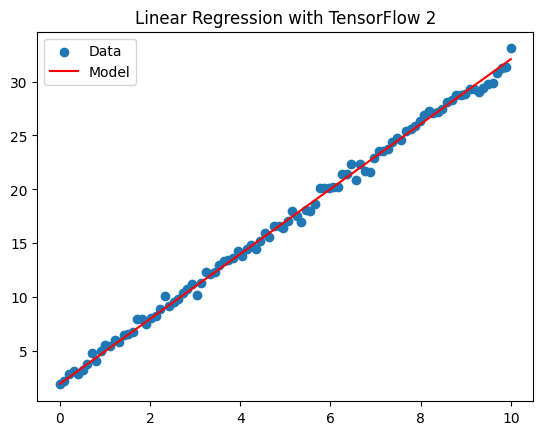

In [ ]:
# # Build a simple linear regression model using TensorFlow 2 to learn the relationship y = 3x + 2 from synthetic data.

# import tensorflow as tf
# import numpy as np
# import matplotlib.pyplot as plt

# # Generate Synthetic training data
# X = np.linspace(0, 10, 100) # 100 evenly spaced values from 0 to 10
# y = 3 * X + 2 + np.random.randn(*X.shape) * 0.5 # Linear relation with noise

# # Create a Simple Sequential model with one Dense unit
# model = tf.keras.Sequential([
#     tf.keras.layers.Dense(units=1, input_shape=[1]) # One neuron, input is 1D
# ])

# # compile the model with mean squared error loss and SGD optimizer 
# model.compile(optimizer='sgd', loss='mse') # Optimizer: SGD, Loss: Mean Squared Error

# # Train the model
# model.fit(X, y, epochs=100, verbose=0)  # Train for 100 epochs, silent output

# # predict values using Trained model
# predictions = model.predict(X) # Predict for all X values

# # Plot original data and predicted line
# plt.scatter(X, y, label='Data')                        # Scatter plot of original data
# plt.plot(X, predictions, color='red', label='Model')   # Red line: model predictions
# plt.legend()
# plt.title("Linear Regression with TensorFlow 2")
# plt.show()

<!-- ### 2. Logistic Regression Classifier -->

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


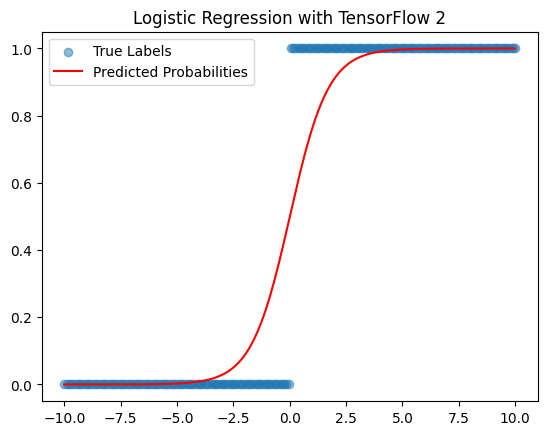

In [ ]:
# # Description:
# # Build a logistic regression model using TensorFlow 2 to classify points based on a binary label. We'll generate synthetic data with a sigmoid decision boundary.

# import tensorflow as tf
# import numpy as np
# import matplotlib.pyplot as plt

# # Generate synthetic binary classification data
# X = np.linspace(-10, 10, 200).reshape(-1, 1)                  # 200 points between -10 and 10
# y = (1 / (1 + np.exp(-0.8 * X))).reshape(-1) > 0.5           # Sigmoid function + threshold at 0.5
# y = y.astype(np.float32)                                     # Convert boolean to float (0 or 1)
 
# # Create a logistic regression model
# model = tf.keras.Sequential([
#     tf.keras.layers.Dense(units=1, activation='sigmoid', input_shape=[1])  # 1 neuron with sigmoid activation
# ])
 
# # Compile the model with binary crossentropy and SGD optimizer
# model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
 
# # Train the model
# model.fit(X, y, epochs=100, verbose=0)                        # Train for 100 epochs
 
# # Predict probabilities for the input data
# probs = model.predict(X)                                      # Get predicted probabilities
# preds = (probs > 0.5).astype(np.float32)                      # Threshold at 0.5 to classify
 
# # Plot the results
# plt.scatter(X, y, label='True Labels', alpha=0.5)             # Original data points
# plt.plot(X, probs, color='red', label='Predicted Probabilities') # Predicted sigmoid curve
# plt.title("Logistic Regression with TensorFlow 2")
# plt.legend()
# plt.show()

<!-- ### 3. Multilayer Perceptron from Scratch -->

In [ ]:
# Create a basic feedforward neural network (MLP) using TensorFlow 2 to classify data from the Iris dataset (3 classes).

import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from computer_vision_projects.Pneumonia_classifier.Pneumonia import optimizer

# Load Iris Dataset
iris = load_iris()
X = iris.data # Features: sepal & petal length/width
y = iris.target.reshape(-1, 1) # Labels: 0, 1, 2

# One-hot encode labels for multi-class classification
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y) # Convert to one-hot format

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Normalize features

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state = 42)

# Define the MLP model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(4,)),  # First hidden layer with 10 ReLU unit
    tf.keras.layers.Dense(8, activation='relu'), # Second hidden layer with 8 ReLU units
    tf.keras.layers.Dense(3, activation='softmax')  # Output layer with softmax for 3 classes
])

# Compile the model with categorical crossentropy and Adam optimizer
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
epoch = 100
model.fit(X_train, y_train, epochs=epoch, verbose=0)        # Train silently for 100 epochs

# Evaluate the model on the test set
loss, acc = model.evaluate(X_test, y_test, verbose=0)     # Evaluate model performance
print(f"Epoch: {epoch}, Test accuracy: {acc:.2f}")

<!-- ### 4. Training with GradientTape -->

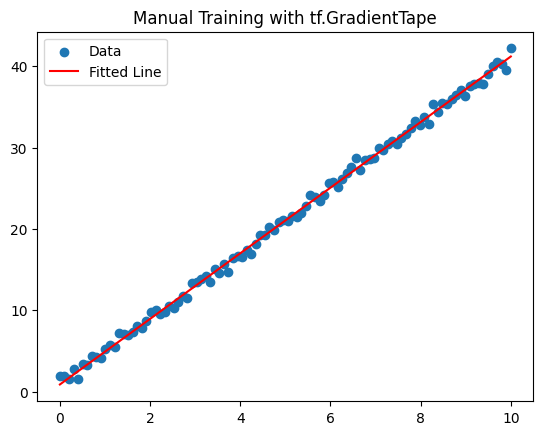

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
 
# Generate synthetic data
X = np.linspace(0, 10, 100).astype(np.float32)             # 100 input values from 0 to 10
y = 4 * X + 1 + np.random.randn(*X.shape) * 0.5             # Target: linear relation + noise
 
# Convert to tensors
X_tensor = tf.convert_to_tensor(X.reshape(-1, 1), dtype=tf.float32)           # Reshape to column vector
y_tensor = tf.convert_to_tensor(y.reshape(-1, 1), dtype=tf.float32)           # Reshape to column vector
 
# Initialize weight and bias variables
W = tf.Variable(tf.random.normal([1, 1]))                   # Weight initialized randomly
b = tf.Variable(tf.zeros([1]))                              # Bias initialized as zero

# Set learning rate and number of epochs
lr = 0.01
epochs = 200

# Training loop using GradientTape
for epoch in range(epochs):
    with tf.GradientTape() as tape:                         # Record operations for auto-diff
        y_pred = tf.matmul(X_tensor, W) + b                 # Compute predictions: y = Wx + b
        loss = tf.reduce_mean(tf.square(y_pred - y_tensor))# Mean Squared Error loss
 
    gradients = tape.gradient(loss, [W, b])                 # Compute gradients w.r.t W and b
    W.assign_sub(lr * gradients[0])                         # Update weights
    b.assign_sub(lr * gradients[1])                         # Update bias
 
# Make predictions after training
y_pred = tf.matmul(X_tensor, W) + b                         # Final prediction line
 
# Plot results
plt.scatter(X, y, label='Data')                             # Plot original data
plt.plot(X, y_pred.numpy(), color='red', label='Fitted Line') # Plot regression line
plt.title("Manual Training with tf.GradientTape")
plt.legend()
plt.show()

### 5. Custom Loss and Metrcis

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


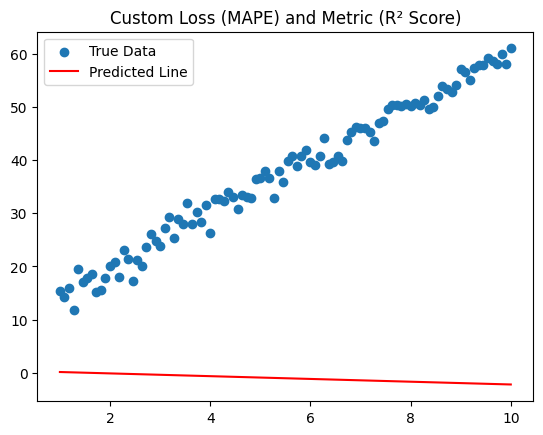

In [3]:
# Implement a custom Mean Absolute Percentage Error (MAPE) loss function and a custom R² score metric to evaluate a regression model using TensorFlow 2.

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic regression data
X = np.linspace(1, 10, 100).astype(np.float32) # Input values from 1 to 10
y = 5 * X + 10 + np.random.randn(*X.shape) * 2  # Linear relation with noise

# Define a custom MAPE loss function
def custom_mape(y_true, y_pred):
    return tf.reduce_mean(tf.abs((y_true - y_pred) / y_true)) * 100 # MAPE formula

# Define a custom R² (coefficient of determination) metric
def r2_score(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred)) #  Residual sum of squares
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true))) # Total Sum of squares
    return 1 - ss_res / ss_tot # R² formula

# Create a Simple linear model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1]) # Single neuron for linear regression
])

# Compile the model using custom loss and metric
model.compile(optimizer='adam', loss=custom_mape, metrics=[r2_score])

# Train the model
model.fit(X, y, epochs=100, verbose=0) # Train for 100 epochs silently

# Predict using the trained model
preds = model.predict(X)

# Plot predictions
plt.scatter(X, y, label='True Data')                           # Scatter plot of actual data
plt.plot(X, preds, color='red', label='Predicted Line')        # Plot predicted line
plt.title("Custom Loss (MAPE) and Metric (R² Score)")
plt.legend()
plt.show()


### 6. Batch Normalization Demo

In [ ]:
# Demonstrate how adding Batch Normalization to a neural network can improve training stability and convergence on noisy data.

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Generate Synthetic noisy classification data
X = np.linspace(-3, 3, 500).reshape(-1, 1) # Input values from -3 to 3
y = (X[:, 0] > 0).astype(np.float32).reshape(-1, 1) # Labels: 1 if x > 0 else 0

# Define model without Normalization
model_no_bn = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=[1]), # Hidden layer
    tf.keras.layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Model with Normalization
model_with_bn = tf.keras.Sequential([
    tf.keras.layers.Dense(32, input_shape=[1]), # Hidden layer without activation first
    tf.keras.layers.BatchNormalization(), # Normalize before activation
    tf.keras.layers.Activation('relu'), # Apply ReLU after normalization
    tf.keras.layers.Dense(1, activation='sigmoid') # output layer
])

# Compile both models
model_no_bn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_with_bn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train both models
history_no_bn = model_no_bn.fit(X, y, epochs=50, verbose=0, validation_split=0.2)
history_with_bn = model_with_bn.fit(X, y, epochs=50, verbose=0, validation_split=0.2)

# Plot validation accuracy comparison
plt.plot(history_no_bn.history['val_accuracy'], label='Without BatchNorm') # Accuracy without BN

plt.title("Effect of Batch Normalization on Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

plt.plot(history_with_bn.history['val_accuracy'], label='With BatchNorm') # Accuracy with BN
plt.title("Effect of Batch Normalization on Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()


### 7. Learning Rate Scheduling

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


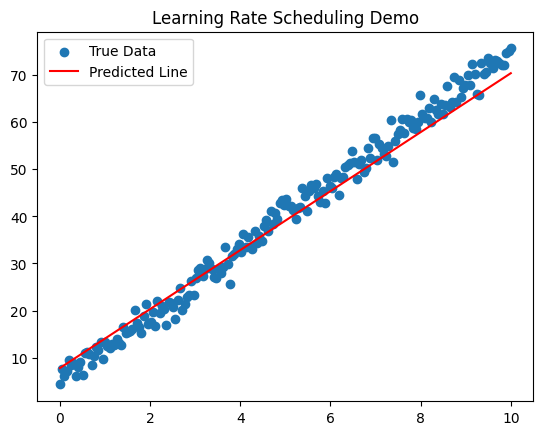

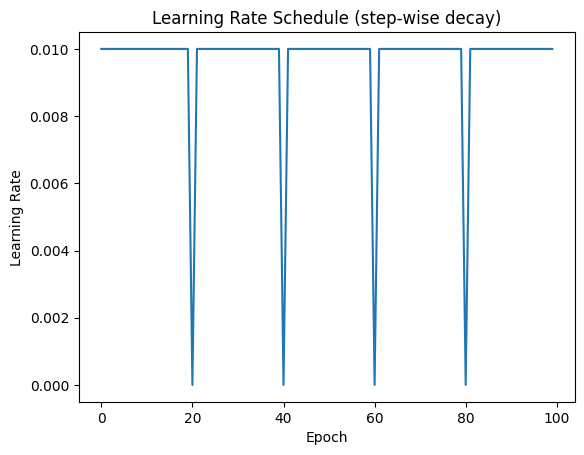

In [3]:
# Description:
# Demonstrate how to use a learning rate scheduler in TensorFlow 2 to adaptively reduce the learning rate during training for a regression task.

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic regression data
X = np.linspace(0, 10, 200).reshape(-1, 1).astype(np.float32)      # Inputs: 0 to 10
y = 7 * X + 5 + np.random.randn(*X.shape) * 2                      # Targets: linear + noise

# Define a learning rate scheduler function
def scheduler(epoch, lr):
    if epoch % 20 == 0 and epoch:
        return lr * 0. # Halve learning rate every 20 epochs
    return lr

# Create a simple regression model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1]) # Single neuron linear regressor
])

# Compile with Adam optimizer and MSE loss
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss='mse')

# Use the scheduler as a callback
lr_callback = tf.keras.callbacks.LearningRateScheduler(scheduler)

# Train the model with scheduler
history = model.fit(X, y, epochs=100, callbacks=[lr_callback], verbose=0)

# Predict and visualize results
preds = model.predict(X)

plt.scatter(X, y, label='True Data')                               # Original noisy data
plt.plot(X, preds, color='red', label='Predicted Line')            # Regression line
plt.title("Learning Rate Scheduling Demo")
plt.legend()
plt.show()

# Plot learning rate change over epochs
lrs = [scheduler(e, 0.01) for e in range(100)]
plt.plot(lrs)
plt.title("Learning Rate Schedule (step-wise decay)")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.show()


### 8.  Early Stopping & Model Checkpointing

In [ ]:
# Description:
# Show how to use early stopping to prevent overfitting and save the best model using model checkpointing during training.

import tensorflow as tf
import numpy as np
import os

# Create synthetic regression data
X = np.linspace(0, 10, 300).reshape(-1, 1).astype(np.float32) # Inputs from 0 to 10
y = 2 * X + 3 + np.random.randn(*X.shape) * 0.5 # Target with noise

# Define a simple feedforward model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=[1]),   # Hidden layer
    tf.keras.layers.Dense(1)                                         # Output layer
])


# Compile with MSE loss and Adam optimizer
model.compile(optimizer='adam', loss='mse', metrics=['mae'])  # Mean Absolute Error as metric

# setup callbacks: Earlystopping and ModelCheckpoint
early_stop = tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True) # Stop if no improvement
checkpoint_path = 'best_model.h5' #path to save best model
checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True)


# Train with callbacks
history = model.fit(X, y, epochs=100, validation_split=0.2,
                    callbacks=[early_stop, checkpoint], verbose=0)

# Load best model weights (optional — already restored if early_stop.restore_best_weights=True)
model.load_weights(checkpoint_path)

# Evaluate final model
loss, mae = model.evaluate(X, y, verbose=0)
print(f"Final MAE: {mae:.3f}")

### 9. Binary Classification on Tabular Data

In [2]:
# rain a binary classification model on the Pima Indians Diabetes dataset using TensorFlow 2 and evaluate its accuracy.

import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Pima Indians Diabetes from UCI (via Url)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
        "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
df = pd.read_csv(url, names=cols)

X = df.drop("Outcome", axis=1).values
y = df['Outcome'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Build a binary classification model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=[X.shape[1]]), # Hidden layer
    tf.keras.layers.Dense(8, activation='relu'), # Hidden layer
    tf.keras.layers.Dense(1, activation='sigmoid') #output layer for binary prob
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=50, verbose=0, validation_split=0.1)

# Evaluate on test set
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Accuracy: {acc:.3f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final Accuracy: 0.779


### 10.Multi-Class Classification on Fashion MNIST

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8217 - loss: 0.5076 - val_accuracy: 0.8617 - val_loss: 0.3859
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8639 - loss: 0.3805 - val_accuracy: 0.8720 - val_loss: 0.3642
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8771 - loss: 0.3389 - val_accuracy: 0.8710 - val_loss: 0.3501
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8855 - loss: 0.3146 - val_accuracy: 0.8770 - val_loss: 0.3501
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8907 - loss: 0.2945 - val_accuracy: 0.8820 - val_loss: 0.3347
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8952 - loss: 0.2828 - val_accuracy: 0.8800 - val_loss: 0.3365
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8987 - loss: 0.2702 - val_accuracy: 0.8822 - val_loss: 0.3346
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9033 - loss: 0.2584 - 

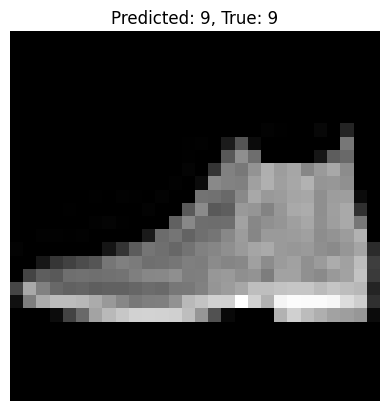

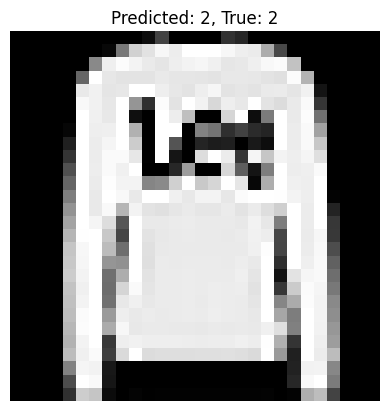

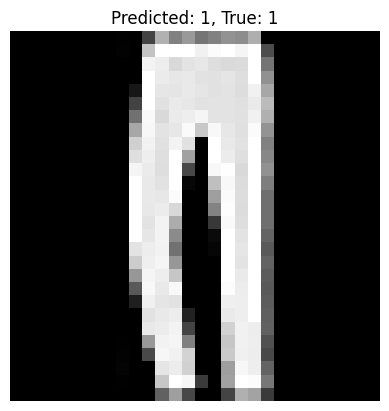

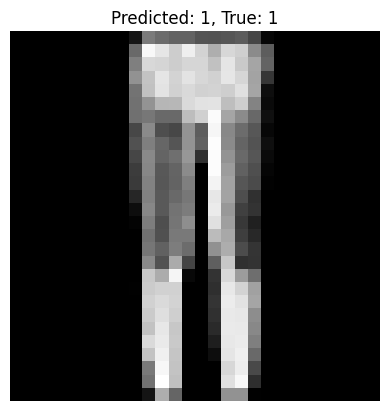

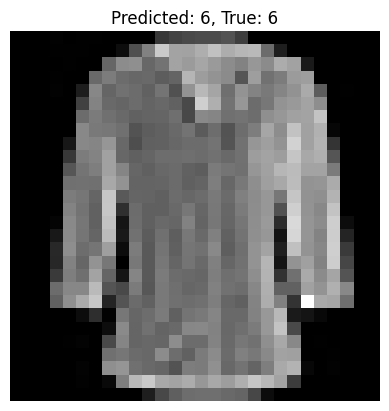

In [3]:
# Train a neural network using TensorFlow 2 to classify clothing images from the Fashion MNIST dataset into 10 categories.
import tensorflow as tf
import matplotlib.pyplot as plt

# Load the Fashion MNIST dataset from Keras
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to range [0, 1]
X_train = X_train / 255.0                                       # Scale training images
X_test = X_test / 255.0                                         # Scale test images

# Build the model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),             # Flatten 28x28 images to 784
    tf.keras.layers.Dense(128, activation='relu'),             # Hidden layer with 128 ReLU units
    tf.keras.layers.Dense(10, activation='softmax')            # Output layer for 10 classes
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, validation_split=0.1, verbose=1)  # Include validation split

# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.2f}")

# Optional: Display sample predictions
preds = model.predict(X_test[:5])                            # Predict on first 5 test images
for i, pred in enumerate(preds):
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Predicted: {pred.argmax()}, True: {y_test[i]}")
    plt.axis('off')
    plt.show()


### 11. Image Normalization Pipeline

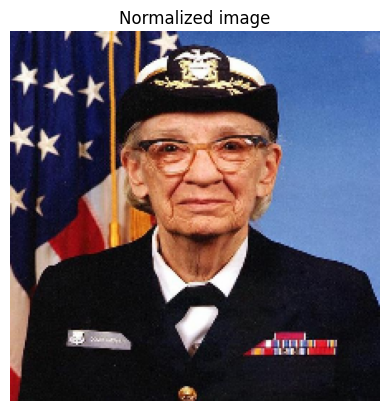

In [6]:
# Create a TensorFlow image pipeline that reads, decodes, resizes, and normalizes images to feed into a neural network model.

import tensorflow as tf
import matplotlib.pyplot as plt

# Example image path
image_path = tf.keras.utils.get_file("grace_hopper.jpg", "https://storage.googleapis.com/download.tensorflow.org/example_images/grace_hopper.jpg")

# Function to load and preprocess an image
def preprocess_image(path):
    img_raw = tf.io.read_file(path) # Read image file as binary
    img = tf.image.decode_jpeg(img_raw, channels=3)  # Decode JPEG to tensor with 3 color channels
    img = tf.image.resize(img, [224, 224]) # resize image to 224x224
    img = tf.cast(img, tf.float32) / 255.0 # Normalize pixel values to [0, 1]
    return img

# Preprocess the image
image = preprocess_image(image_path)

# Display the processed image
plt.imshow(image)
plt.title("Normalized image")
plt.axis("off")
plt.show()

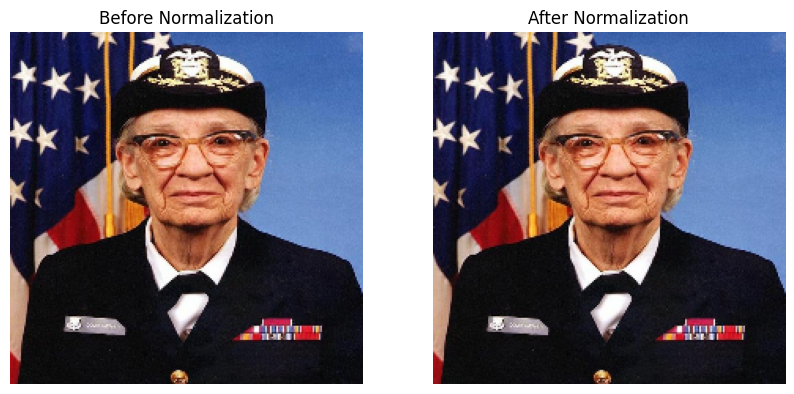

In [8]:
# Function to load and preprocess an image
def preprocess_image(path, normalize=True):
    img_raw = tf.io.read_file(path)  # Read image file as binary
    img = tf.image.decode_jpeg(img_raw, channels=3)  # Decode JPEG to tensor with 3 color channels
    img = tf.image.resize(img, [224, 224])  # Resize image to 224x224
    if normalize:
        img = tf.cast(img, tf.float32) / 255.0  # Normalize pixel values to [0, 1]
    else:
        img = tf.cast(img, tf.uint8)  # Keep original pixel values (0–255)
    return img

# Preprocess the image without normalization
image_before_norm = preprocess_image(image_path, normalize=False)

# Preprocess the image with normalization
image_after_norm = preprocess_image(image_path, normalize=True)

# Display both images side by side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_before_norm)
plt.title("Before Normalization")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_after_norm)
plt.title("After Normalization")
plt.axis("off")

plt.show()

### 12. Train/Validation/Test Split Utility

In [2]:
# Implement a utility function using TensorFlow's tf.data API to split image data into training, validation, and test sets from a directory.

import tensorflow as tf
import os

# Load image datasets from directory
dataset_url = "https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip"
path_to_zip = tf.keras.utils.get_file('cats_and_dogs_filtered.zip', origin=dataset_url, extract=True)
data_dir = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_filtered', 'train') # Use train set

# Function to create split dataset
def create_split_dataset(data_dir, img_size=(160, 160), batch_size=32, val_split=0.2, test_split=0.1):
    # First, Split into training and validation
    full_dataset = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        image_size= img_size,
        batch_size=batch_size,
        validation_split=val_split + test_split, # Reserve both val + test initially
        subset = 'training',
        seed=123
    )

    valtest_dataset = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        image_size=img_size,
        batch_size=batch_size,
        validation_split=val_split + test_split,
        subset="validation",
        seed=123
    )

    val_batches = int(val_split / (val_split + test_split) * len(valtest_dataset)) # Split into val and test

    val_dataset = valtest_dataset.take(val_batches) # First part = validation set
    test_dataset = valtest_dataset.skip(val_batches) # Remaining part = test set

    return full_dataset, val_dataset, test_dataset

# Generate datasets
train_ds, val_ds, test_ds = create_split_datasets(data_dir)

# Print dataset sizes
print(f"Train batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Test batches: {len(test_ds)}")

Exception: URL fetch failure on https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip: 403 -- Forbidden

In [1]:
import tensorflow as tf
import os

# Paths to your dataset folders
train_dir = r"C:\Users\Usha Biratthi\Downloads\antigravity\udemy\projects\week3\day13\cat_dog_train"
test_dir  = r"C:\Users\Usha Biratthi\Downloads\antigravity\udemy\projects\week3\day13\cat_dog_test"

def create_split_dataset(train_dir, test_dir, img_size=(160, 160), batch_size=32, val_split=0.2, seed=123):
    # Training dataset (with validation split)
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        image_size=img_size,
        batch_size=batch_size,
        validation_split=val_split,
        subset="training",
        seed=seed
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        image_size=img_size,
        batch_size=batch_size,
        validation_split=val_split,
        subset="validation",
        seed=seed
    )

    # Test dataset (separate folder)
    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        image_size=img_size,
        batch_size=batch_size,
        shuffle=False
    )

    return train_ds, val_ds, test_ds

# Generate datasets
train_ds, val_ds, test_ds = create_split_dataset(train_dir, test_dir)

print(f"Train batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Test batches: {len(test_ds)}")


Found 4186 files belonging to 2 classes.
Using 3349 files for training.
Found 4186 files belonging to 2 classes.
Using 837 files for validation.
Found 2023 files belonging to 2 classes.
Train batches: 105
Validation batches: 27
Test batches: 64


In [2]:
import tensorflow as tf
import os
import zipfile

# Path to your dataset zip file
zip_path = r"C:\Users\Usha Biratthi\Downloads\antigravity\dataset\Cat and dog.zip"

# Extract the zip file
extract_dir = os.path.splitext(zip_path)[0]  # removes ".zip"
if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

# Now point TensorFlow to the extracted folder
data_dir = extract_dir  # should contain subfolders like 'cats' and 'dogs'

def create_split_dataset(data_dir, img_size=(160, 160), batch_size=32, val_split=0.2, test_split=0.1, seed=123):
    # Training dataset
    train_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        image_size=img_size,
        batch_size=batch_size,
        validation_split=val_split + test_split,
        subset="training",
        seed=seed
    )

    # Validation + Test dataset
    valtest_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        image_size=img_size,
        batch_size=batch_size,
        validation_split=val_split + test_split,
        subset="validation",
        seed=seed
    )

    # Split valtest into validation and test
    val_batches = int(val_split / (val_split + test_split) * len(valtest_ds))
    val_ds = valtest_ds.take(val_batches)
    test_ds = valtest_ds.skip(val_batches)

    return train_ds, val_ds, test_ds

# Generate datasets
train_ds, val_ds, test_ds = create_split_dataset(data_dir)

print(f"Train batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Test batches: {len(test_ds)}")


Found 10028 files belonging to 2 classes.
Using 7020 files for training.
Found 10028 files belonging to 2 classes.
Using 3008 files for validation.
Train batches: 220
Validation batches: 62
Test batches: 32


c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 163s 705ms/step - accuracy: 0.7932 - loss: 0.5694 - val_accuracy: 0.7994 - val_loss: 0.5139
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 191s 853ms/step - accuracy: 0.7983 - loss: 0.5099 - val_accuracy: 0.7994 - val_loss: 0.5056
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 325s 1s/step - accuracy: 0.7989 - loss: 0.4896 - val_accuracy: 0.7984 - val_loss: 0.5204
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 542s 816ms/step - accuracy: 0.8189 - loss: 0.4309 - val_accuracy: 0.7858 - val_loss: 0.5485
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 481s 2s/step - accuracy: 0.8497 - loss: 0.3638 - val_accuracy: 0.7681 - val_loss: 0.6921
32/32 ━━━━━━━━━━━━━━━━━━━━ 54s 200ms/step - accuracy: 0.7656 - loss: 0.6774
Test Accuracy: 0.7656


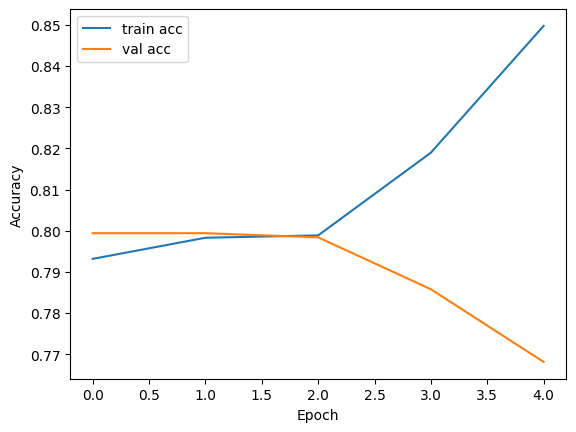

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
Prediction: Dog (confidence: 0.76)


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Normalize and prefetch datasets
AUTOTUNE = tf.data.AUTOTUNE
def prepare(ds):
    return ds.map(lambda x, y: (tf.cast(x, tf.float32)/255.0, y)).cache().prefetch(buffer_size=AUTOTUNE)

train_ds = prepare(train_ds)
val_ds   = prepare(val_ds)
test_ds  = prepare(test_ds)

# Build a simple CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(160,160,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # binary classification (cat vs dog)
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=5)

# Evaluate on test dataset
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

# Plot training history
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# --- Prediction on new image ---
import pathlib

def predict_image(model, img_path):
    img = tf.keras.utils.load_img(img_path, target_size=(160,160))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) / 255.0  # normalize and add batch dimension

    prediction = model.predict(img_array)[0][0]
    label = "Dog" if prediction > 0.5 else "Cat"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    print(f"Prediction: {label} (confidence: {confidence:.2f})")

# Example usage (replace with your own image path)
predict_image(model, r"C:\Users\Usha Biratthi\Downloads\antigravity\ML_lib\tensorflow\cat_dog_test\dogs\dog.4002.jpg")


In [6]:
predict_image(model, r"C:\Users\Usha Biratthi\Downloads\antigravity\ML_lib\tensorflow\cat_dog_test\cats\cat.4002.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Prediction: Dog (confidence: 0.89)


### 13.ensorBoard Logging Visualizer

In [1]:
# Use TensorBoard to monitor training metrics such as loss and accuracy by logging them during model training.

import tensorflow as tf
import datetime

# Load and normalize MNIST dataset
(X_train, y_train), _ = tf.keras.datasets.mnist.load_data()        # Use only training data
X_train = X_train / 255.0                                          # Normalize pixel values
X_train = X_train[..., tf.newaxis]                                 # Add channel dimension (28,28,1)
 
# Create a simple CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=(28, 28, 1)),  # Conv layer
    tf.keras.layers.Flatten(), # Flatten for Dense layer
    tf.keras.layers.Dense(64, activation='relu'),                              # Hidden layer
    tf.keras.layers.Dense(10, activation='softmax')                            # Output layer
])
 
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
 
# Set up TensorBoard log directory
log_dir = "logs/tensorboard_demo/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
 
# Create TensorBoard callback
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
 
# Train the model with TensorBoard callback
model.fit(X_train, y_train, epochs=5, validation_split=0.2, callbacks=[tensorboard_cb], verbose=0)
 
# To launch TensorBoard, run this command in a separate terminal (not in Python):
# tensorboard --logdir=logs/tensorboard_demo/

c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 14.TensorFlow Datasets (tfds) Loader

In [3]:
# Use tensorflow_datasets (TFDS) to easily load and preprocess standard datasets like mnist, cifar10, or rock_paper_scissors with built-in train/test splits.

import tensorflow_datasets as tfds
import tensorflow as tf

# Load the CIFAR-10 dataset using TFDS
(ds_train, ds_test), ds_info = tfds.load(
    'cifar10',
    split=['train', 'test'], # Specify train/test splits
    shuffle_files=True, # Shuffle data files
    as_supervised=True, # Return (image, label) pairs
    with_info=True, # Get metadata about the dataset
)

# Normalize and batch the data
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0 # Normal image pixels to [0, 1]
    return image, label

batch_size = 32
ds_train = ds_train.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)  # Map, batch, prefetch
ds_test = ds_test.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Build a Simple CNN Model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=(32, 32, 3)),# Conv layer
    tf.keras.layers.MaxPooling2D(), # Pooling layer
    tf.keras.layers.Flatten(), # Flatten before Dense
    tf.keras.layers.Dense(64, activation='relu'), #  Hidden layer
    tf.keras.layers.Dense(10, activation='softmax') # Output for 10 classes
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(ds_train, epochs=5, validation_data=ds_test, verbose=1)

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(ds_test, verbose=1)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.4612 - loss: 1.5053 - val_accuracy: 0.5262 - val_loss: 1.3328
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5722 - loss: 1.2146 - val_accuracy: 0.5745 - val_loss: 1.2072
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6115 - loss: 1.1114 - val_accuracy: 0.5924 - val_loss: 1.1583
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6363 - loss: 1.0387 - val_accuracy: 0.6021 - val_loss: 1.1395
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6575 - loss: 0.9797 - val_accuracy: 0.6150 - val_loss: 1.1073
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6150 - loss: 1.1073
Test Accuracy: 0.6150
Test Loss: 1.1073


### 15. TensorFlow Hub Pretrained Model Demo

In [8]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
import requests

# 1. Load the model
model_url = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4"
model = hub.load(model_url)

# 2. Use a browser-like header to bypass the 403 Forbidden error
headers = {'User-Agent': 'Mozilla/5.0'}
image_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/puppy.jpg"

response = requests.get(image_url, headers=headers)

if response.status_code == 200:
    # 3. Decode the image
    img = tf.io.decode_image(response.content, channels=3, expand_animations=False)
    img = tf.image.resize(img, [224, 224])
    img = img / 255.0
    image = tf.expand_dims(img, axis=0)

    # 4. Perform prediction
    predictions = model(image)

    # Load labels
    labels_url = "https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt"
    labels_response = requests.get(labels_url, headers=headers)
    imagenet_labels = np.array(labels_response.text.splitlines())

    predicted_class = np.argmax(predictions[0])
    predicted_label = imagenet_labels[predicted_class]

    # 5. Visualization
    plt.imshow(tf.squeeze(image))
    plt.title(f"Predicted: {predicted_label}")
    plt.axis('off')
    plt.show()
else:
    print(f"Failed to download image. Status code: {response.status_code}")

Failed to download image. Status code: 403


In [1]:
pip install tensorflow_hub


  Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached tf_keras-2.21.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached protobuf-7.35.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl (30 kB)
Using cached tf_keras-2.21.0-py3-none-any.whl (1.7 MB)
Using cached protobuf-7.35.0-cp310-abi3-win_amd64.whl (439 kB)

  Attempting uninstall: protobuf

    Found existing installation: protobuf 5.29.6

   ---------------------------------------- 0/3 [protobuf]
    Uninstalling protobuf-5.29.6:
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
      Successfully uninstalled protobuf-5.29.6
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   -----------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.0 which is incompatible.
mediapipe 0.10.9 requires protobuf<4,>=3.11, but you have protobuf 7.35.0 which is incompatible.
streamlit 1.41.1 requires protobuf<6,>=3.20, but you have protobuf 7.35.0 which is incompatible.


c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


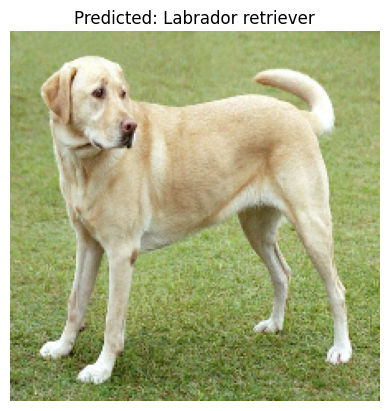

In [2]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the model (Hub handles local caching effectively)
model_url = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4"
model = hub.load(model_url)

# 2. Load labels from local file
# Ensure ImageNetLabels.txt is in your local folder
with open('ImageNetLabels.txt', 'r') as f:
    imagenet_labels = np.array(f.read().splitlines())

# 3. Load image from local file
# Ensure puppy.jpg is in your local folder
def load_and_preprocess_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [224, 224])
    img = img / 255.0
    return tf.expand_dims(img, axis=0)

image = load_and_preprocess_image('puppy.jpg')

# 4. Perform prediction
predictions = model(image)
predicted_class = np.argmax(predictions[0])
predicted_label = imagenet_labels[predicted_class]

# 5. Visualization
plt.imshow(tf.squeeze(image))
plt.title(f"Predicted: {predicted_label}")
plt.axis('off')
plt.show()

In [1]:
import tensorflow as tf
import os

# Define local paths
local_file_name = 'ImageNetLabels.txt'
origin_url = 'https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt'

# Use Keras's built-in file management, which handles caching and local persistence
# This is preferred in digital design as it ensures the file exists locally
# for the duration of the application lifetime.
try:
    labels_path = tf.keras.utils.get_file(
        fname=local_file_name,
        origin=origin_url,
        cache_subdir='datasets',
        extract=False
    )
    print(f"File successfully retrieved at: {labels_path}")
except Exception as e:
    print(f"Could not reach remote source: {e}. Please manually download to your working directory.")

# Verification of file integrity and contents
with open(labels_path, 'r') as f:
    labels = f.read().splitlines()
    print(f"Loaded {len(labels)} class labels.")

10484/10484 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
File successfully retrieved at: C:\Users\Usha Biratthi\.keras\datasets\ImageNetLabels.txt
Loaded 1001 class labels.
